# WEKEO Template
A notebook to show hot to accesse, search and download a dataset from WEKEO. Wekeo provides the hda Python package to connect to its web service.

In [18]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from hda import Client, Configuration
from zipfile import ZipFile
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy
from platform import python_version
import warnings
warnings.filterwarnings('ignore')
print("python version: %s"%python_version())
print("pandas version: %s"%pd.__version__)
print("xarray version: %s"%xr.__version__)

python version: 3.12.5
pandas version: 2.2.2
xarray version: 2024.7.0


In [2]:
bb_north = 47.50379785942417
bb_south = 34.82621887953009
bb_west = 5.899000073477433
bb_east = 20.721255946087158
variable = "2m_temperature"

In [20]:
query = {
  "datasetId": "EO:ECMWF:DAT:REANALYSIS_ERA5_LAND",
  "boundingBoxValues": [
    {
      "name": "area",
      "bbox": [
        bb_west,
        bb_north,
        bb_east,
        bb_south
      ]
    }
  ],
  "multiStringSelectValues": [
    {
      "name": "variable",
      "value": [
        variable
      ]
    },
    {
      "name": "year",
      "value": [
        "2022"
      ]
    },
    {
      "name": "month",
      "value": [
        "04",
        "05"
      ]
    },
    {
      "name": "day",
      "value": [
        "01", "02", "03", "04", "05", 
        "06", "08", "07", "09", "10", 
        "11", "12", "13", "14", "15",
        "16", "17", "18", "19", "20", 
        "21", "22", "23", "24", "25", 
        "26", "27", "28", "29", "30", 
        "31"
      ]
    },
    {
      "name": "time",
      "value": [
        "00:00", "03:00", "06:00",
        "09:00", "12:00", "15:00",
        "18:00", "21:00"
      ]
    }
  ],
  "stringChoiceValues": [
    {
      "name": "format",
      "value": "netcdf"
    }
  ]
}

In [4]:
DATADIR = 'data/'

In [5]:
Path.home()

WindowsPath('C:/Users/Luigi')

In [6]:
from pathlib import Path
hdarc = Path(Path.home() / '.hdarc')
hdarc

WindowsPath('C:/Users/Luigi/.hdarc')

In [7]:
with open(hdarc) as f:
    user = f.readline().strip().split('=')[1]
    password = f.readline().strip().split('=')[1]

In [8]:
conf = Configuration(user=user, password=password)
c = Client(config=conf)
matches = c.search(query)
matches.download(DATADIR)

In [9]:
import glob, os
for file in glob.glob(DATADIR + '*.zip'):
    file_name = file

In [10]:
file_name

'data\\reanalysis-era5-land-c4972885b57e45bcfcbe69cd71308224.zip'

In [11]:
with ZipFile(file_name, 'r') as zipObj:
   zipObj.extractall(path=f'{DATADIR}/')

In [12]:
for file in glob.glob(DATADIR + '*.nc'):
    ncdf_file_name = file

In [13]:
ncdf_file_name

'data\\data_0.nc'

In [14]:
os.rename(ncdf_file_name, DATADIR + '2m_temperature.nc')

In [15]:
era5_ds = xr.open_dataset(DATADIR + '2m_temperature.nc')
xr.decode_cf(era5_ds)
era5_ds

<xarray.Dataset> Size: 37MB
Dimensions:     (valid_time: 488, latitude: 127, longitude: 149)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 4kB 2022-04-01 ... 2022-05-31T21:...
  * latitude    (latitude) float64 1kB 47.5 47.4 47.3 47.2 ... 35.1 35.0 34.9
  * longitude   (longitude) float64 1kB 5.9 6.0 6.1 6.2 ... 20.4 20.5 20.6 20.7
    expver      (valid_time) <U4 8kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 37MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-25T11:04 GRIB to CDM+CF via cfgrib-0.9.1...

In [24]:
temperature2m = era5_ds['t2m'].sel(valid_time='2022-04-01T12:00:00')

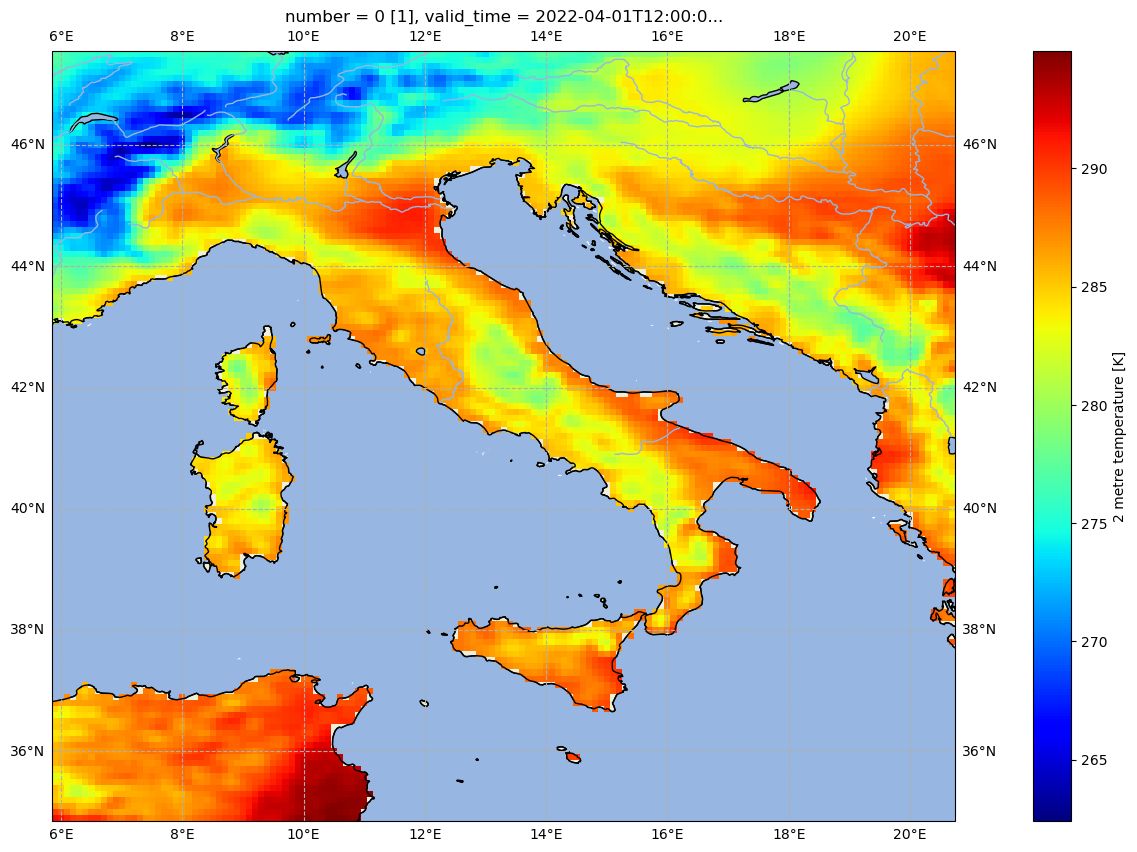

In [26]:
plt.figure(figsize=(20,10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=True, linestyle='--')
ax.add_feature(cartopy.feature.OCEAN)
ax.add_feature(cartopy.feature.LAND, edgecolor='black')
ax.add_feature(cartopy.feature.LAKES, edgecolor='black')
ax.add_feature(cartopy.feature.RIVERS)
ax.coastlines()
temperature2m.plot(ax=ax, add_colorbar=True, cmap='jet')